<a href="https://colab.research.google.com/github/kasrasa/Object-detection-tutorial/blob/Faster-RCNN/Faster_RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision

print("Torch version:", torch.__version__)
print("TorchVision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.11.0+cpu
TorchVision version: 0.26.0+cpu
CUDA available: False
Using device: cpu


In [2]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.ops import box_iou

from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import OrderedDict

def print_tensor_info(name, x):
    """
    Small helper to print tensor shape, dtype, device, min, and max.
    """
    if isinstance(x, torch.Tensor):
        print(f"{name}")
        print(f"  shape: {tuple(x.shape)}")
        print(f"  dtype: {x.dtype}")
        print(f"  device: {x.device}")
        print(f"  min/max: {x.min().item():.4f} / {x.max().item():.4f}")
    else:
        print(f"{name}: {type(x)}")


def show_image_with_boxes(image, boxes=None, scores=None, labels=None, title=None, max_boxes=10):
    """
    image: PIL image
    boxes: Tensor[N, 4] in xyxy format
    """
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image)

    if boxes is not None:
        boxes = boxes.detach().cpu()
        n = min(len(boxes), max_boxes)

        for i in range(n):
            x1, y1, x2, y2 = boxes[i].tolist()
            w = x2 - x1
            h = y2 - y1

            rect = patches.Rectangle(
                (x1, y1),
                w,
                h,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)

            text = ""
            if labels is not None:
                text += f"class={int(labels[i])}"
            if scores is not None:
                text += f" score={float(scores[i]):.2f}"

            if text:
                ax.text(
                    x1,
                    y1,
                    text,
                    bbox=dict(facecolor="white", alpha=0.7),
                    fontsize=9
                )

    if title:
        ax.set_title(title)

    ax.axis("off")
    plt.show()

Original image type: <class 'PIL.Image.Image'>
Original image size: (1546, 1213)


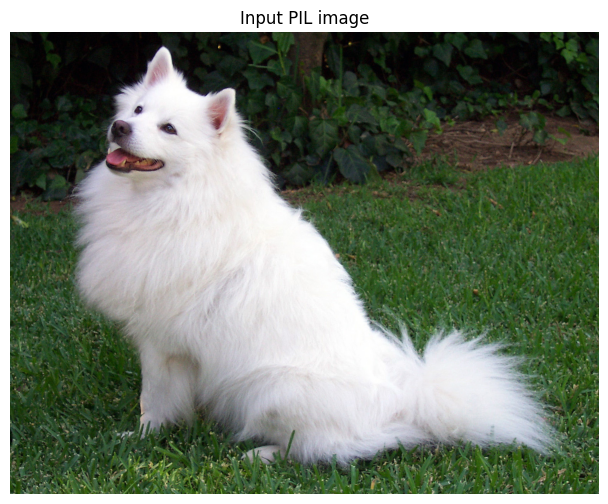

In [3]:
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

print("Original image type:", type(image))
print("Original image size:", image.size)  # width, height

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input PIL image")
plt.show()

In [4]:
image_tensor = torchvision.transforms.functional.to_tensor(image)

images = [image_tensor.to(device)]

print("Number of images:", len(images))
print_tensor_info("images[0]", images[0])

Number of images: 1
images[0]
  shape: (3, 1213, 1546)
  dtype: torch.float32
  device: cpu
  min/max: 0.0000 / 1.0000


In [5]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(weights=weights)
model = model.to(device)
model.eval()

categories = weights.meta["categories"]

print("Number of COCO classes:", len(categories))
print("First 10 categories:", categories[:10])

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 105MB/s]


Number of COCO classes: 91
First 10 categories: ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']


Type of outputs: <class 'list'>
Number of outputs: 1
Keys in outputs[0]: dict_keys(['boxes', 'labels', 'scores'])
final boxes
  shape: (4, 4)
  dtype: torch.float32
  device: cpu
  min/max: 45.0133 / 1471.7245
final labels
  shape: (4,)
  dtype: torch.int64
  device: cpu
  min/max: 17.0000 / 34.0000
final scores
  shape: (4,)
  dtype: torch.float32
  device: cpu
  min/max: 0.1133 / 0.9669

Top detections:
0 label_id: 18 label_name: dog score: 0.9668606519699097 box: [ 137.84052   67.79939 1386.9043  1172.8247 ]
1 label_id: 17 label_name: cat score: 0.3522205948829651 box: [ 134.8363   45.0133 1471.7245 1203.308 ]
2 label_id: 34 label_name: frisbee score: 0.3132008910179138 box: [253.01883 306.1613  406.6772  365.1062 ]
3 label_id: 18 label_name: dog score: 0.11326699703931808 box: [130.7382    62.592003 993.04926  874.35486 ]


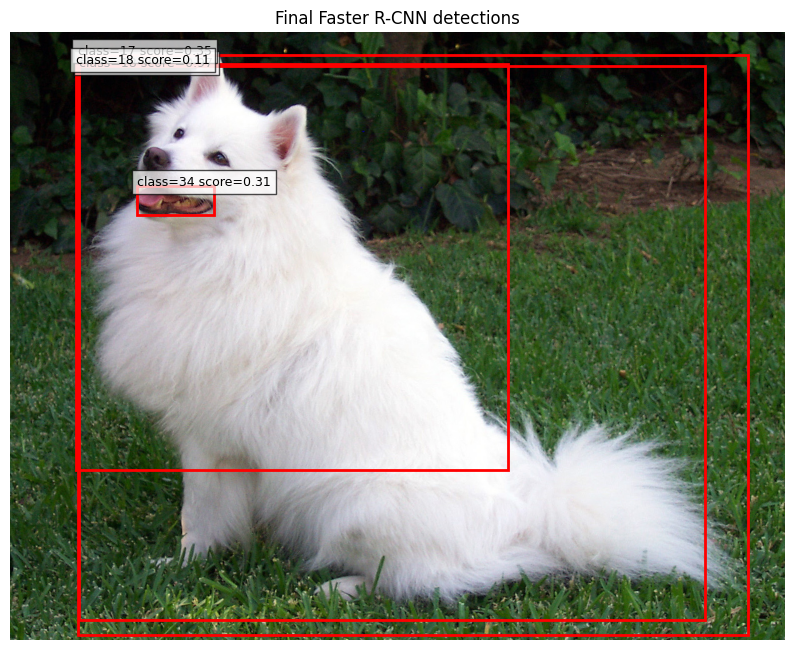

In [6]:
with torch.no_grad():
    outputs = model(images)

print("Type of outputs:", type(outputs))
print("Number of outputs:", len(outputs))
print("Keys in outputs[0]:", outputs[0].keys())

boxes = outputs[0]["boxes"]
labels = outputs[0]["labels"]
scores = outputs[0]["scores"]

print_tensor_info("final boxes", boxes)
print_tensor_info("final labels", labels)
print_tensor_info("final scores", scores)

top_k = 5
print("\nTop detections:")
for i in range(min(top_k, len(boxes))):
    class_id = labels[i].item()
    print(
        i,
        "label_id:", class_id,
        "label_name:", categories[class_id],
        "score:", scores[i].item(),
        "box:", boxes[i].detach().cpu().numpy()
    )

show_image_with_boxes(
    image,
    boxes=boxes,
    scores=scores,
    labels=labels,
    title="Final Faster R-CNN detections",
    max_boxes=5
)

In [7]:
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [8]:
with torch.no_grad():
    transformed_images, targets = model.transform(images, targets=None)

print("Original image size:", image.size)
print("Transformed batch tensor:")
print_tensor_info("transformed_images.tensors", transformed_images.tensors)

print("\nImage sizes after transform:")
print(transformed_images.image_sizes)

Original image size: (1546, 1213)
Transformed batch tensor:
transformed_images.tensors
  shape: (1, 3, 800, 1024)
  dtype: torch.float32
  device: cpu
  min/max: -2.1179 / 2.6400

Image sizes after transform:
[(800, 1019)]


In [9]:
with torch.no_grad():
    features = model.backbone(transformed_images.tensors)

print("Type of features:", type(features))

for name, feat in features.items():
    print_tensor_info(f"feature map {name}", feat)

Type of features: <class 'collections.OrderedDict'>
feature map 0
  shape: (1, 256, 200, 256)
  dtype: torch.float32
  device: cpu
  min/max: -6.3973 / 6.6456
feature map 1
  shape: (1, 256, 100, 128)
  dtype: torch.float32
  device: cpu
  min/max: -6.7340 / 5.7984
feature map 2
  shape: (1, 256, 50, 64)
  dtype: torch.float32
  device: cpu
  min/max: -5.6427 / 7.2038
feature map 3
  shape: (1, 256, 25, 32)
  dtype: torch.float32
  device: cpu
  min/max: -6.9431 / 8.0131
feature map pool
  shape: (1, 256, 13, 16)
  dtype: torch.float32
  device: cpu
  min/max: -6.6543 / 7.3603


In [10]:
with torch.no_grad():
    anchors = model.rpn.anchor_generator(transformed_images, list(features.values()))

print("Number of images:", len(anchors))
print_tensor_info("anchors[0]", anchors[0])

print("\nFirst 5 anchors:")
print(anchors[0][:5])

Number of images: 1
anchors[0]
  shape: (204624, 4)
  dtype: torch.float32
  device: cpu
  min/max: -362.0000 / 1322.0000

First 5 anchors:
tensor([[-23., -11.,  23.,  11.],
        [-16., -16.,  16.,  16.],
        [-11., -23.,  11.,  23.],
        [-19., -11.,  27.,  11.],
        [-12., -16.,  20.,  16.]])


In [12]:
with torch.no_grad():
    objectness, pred_bbox_deltas = model.rpn.head(list(features.values()))

print("Number of feature levels:", len(objectness))

for i, (obj, delta) in enumerate(zip(objectness, pred_bbox_deltas)):
    print(f"\nFeature level {i}")
    print_tensor_info("objectness logits", obj)
    print_tensor_info("bbox deltas", delta)

Number of feature levels: 5

Feature level 0
objectness logits
  shape: (1, 3, 200, 256)
  dtype: torch.float32
  device: cpu
  min/max: -35.9433 / -0.2934
bbox deltas
  shape: (1, 12, 200, 256)
  dtype: torch.float32
  device: cpu
  min/max: -1.7111 / 1.3016

Feature level 1
objectness logits
  shape: (1, 3, 100, 128)
  dtype: torch.float32
  device: cpu
  min/max: -28.6643 / 5.9783
bbox deltas
  shape: (1, 12, 100, 128)
  dtype: torch.float32
  device: cpu
  min/max: -0.8716 / 0.8386

Feature level 2
objectness logits
  shape: (1, 3, 50, 64)
  dtype: torch.float32
  device: cpu
  min/max: -20.1738 / -2.2007
bbox deltas
  shape: (1, 12, 50, 64)
  dtype: torch.float32
  device: cpu
  min/max: -0.8230 / 0.9808

Feature level 3
objectness logits
  shape: (1, 3, 25, 32)
  dtype: torch.float32
  device: cpu
  min/max: -13.5914 / 1.3769
bbox deltas
  shape: (1, 12, 25, 32)
  dtype: torch.float32
  device: cpu
  min/max: -0.8633 / 0.8398

Feature level 4
objectness logits
  shape: (1, 3, 13,